<a href="https://colab.research.google.com/github/sandhiyasudha/machine-learning-project-sandhiya/blob/main/4a_sandhiya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving placement.csv to placement.csv


Dataset Shape: (51, 4)
   cgpa   iq  attendance  placement
0   6.5  110        0.70          1
1   7.5   90        0.80          1
2   7.8  120        0.85          1
3   5.5  140        0.50          0
4   4.0  120        0.70          0
Acceptance Rate: 0.0834

Accuracy: 72.73 %


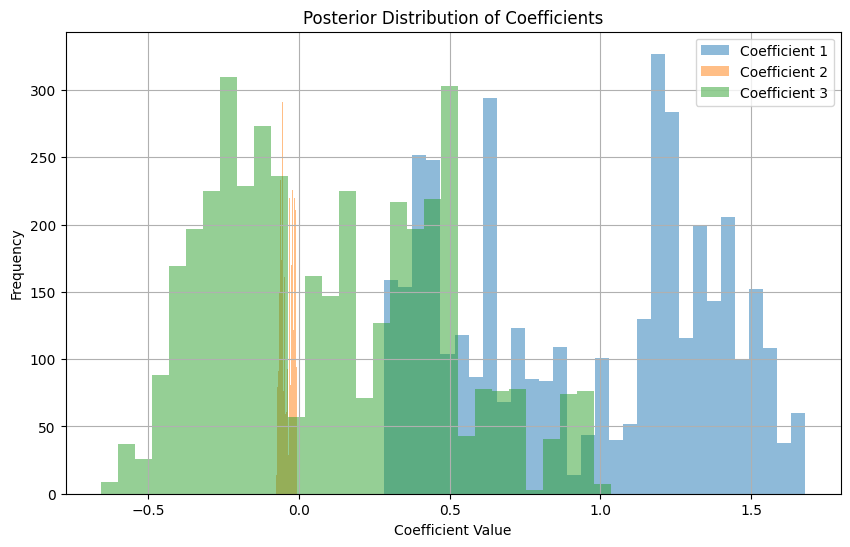

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("placement.csv")

# Remove unwanted column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================
# Features and Target
# ==========================
X = df[['cgpa', 'iq', 'attendance']].values
Y = df['placement'].values

# ==========================
# Train-Test Split
# ==========================
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Add intercept term
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ==========================
# Sigmoid Function
# ==========================
def sigmoid(z):
    z = np.clip(z, -500, 500)  # Prevent overflow
    return 1 / (1 + np.exp(-z))

# ==========================
# Log-Likelihood Function
# ==========================
def log_likelihood(theta, X, Y):
    z = X @ theta
    z = np.clip(z, -500, 500)
    return np.sum(Y * z - np.log1p(np.exp(z)))

# ==========================
# Bayesian Logistic Regression
# ==========================
def bayesian_logistic_regression(
    X,
    Y,
    num_samples=5000,
    burn_in=1000,
    proposal_std=0.05
):

    n_features = X.shape[1]

    theta_current = np.zeros(n_features)

    trace = np.zeros((num_samples, n_features))

    accepted = 0

    current_ll = log_likelihood(theta_current, X, Y)

    for i in range(num_samples):

        proposal = theta_current + np.random.normal(
            0,
            proposal_std,
            n_features
        )

        proposal_ll = log_likelihood(proposal, X, Y)

        log_accept_ratio = proposal_ll - current_ll

        if np.log(np.random.rand()) < log_accept_ratio:
            theta_current = proposal
            current_ll = proposal_ll
            accepted += 1

        trace[i] = theta_current

    print("Acceptance Rate:", accepted / num_samples)

    return trace[burn_in:]

# ==========================
# Train Model
# ==========================
trace = bayesian_logistic_regression(X_train, Y_train)

# Posterior Mean Estimate
theta_mean = np.mean(trace, axis=0)

# ==========================
# Predictions
# ==========================
probabilities = sigmoid(X_test @ theta_mean)

Y_pred = (probabilities >= 0.5).astype(int)

# ==========================
# Accuracy
# ==========================
accuracy = accuracy_score(Y_test, Y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# ==========================
# Plot Coefficient Distributions
# ==========================
plt.figure(figsize=(10, 6))

for i in range(1, trace.shape[1]):
    plt.hist(
        trace[:, i],
        bins=30,
        alpha=0.5,
        label=f'Coefficient {i}'
    )

plt.title("Posterior Distribution of Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()